In [1]:
import csv
from pathlib import Path
from typing import NamedTuple

import grain
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import orbax
import tiktoken
from flax import nnx

In [2]:
class TokenEmbedding(nnx.Module):
    def __init__(self, vocabulary_size: int, embedding_size: int, rngs: nnx.Rngs) -> None:
        self.embedding = nnx.Embed(num_embeddings=vocabulary_size, features=embedding_size, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        return self.embedding(x)


class PositionEmbedding(nnx.Module):
    def __init__(self, max_sequence_length: int, embedding_size: int, rngs: nnx.Rngs) -> None:
        self.embedding = nnx.Embed(num_embeddings=max_sequence_length, features=embedding_size, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        positions = jnp.arange(x.shape[1]).reshape(1, -1)
        return self.embedding(positions)

In [3]:
class LSTMConfig(NamedTuple):
    vocabulary_size: int
    max_sequence_length: int
    num_transformer_blocks: int
    embedding_size: int


class LSTM(nnx.Module):
    def __init__(
        self,
        config: LSTMConfig,
        rngs: nnx.Rngs,
    ) -> None:
        self.token_embedding = TokenEmbedding(
            vocabulary_size=config.vocabulary_size, embedding_size=config.embedding_size, rngs=rngs
        )
        self.position_embedding = PositionEmbedding(
            max_sequence_length=config.max_sequence_length, embedding_size=config.embedding_size, rngs=rngs
        )
        self.first_lstm = nnx.OptimizedLSTMCell(
            rngs=rngs,
            in_features=config.embedding_size,
            hidden_features=config.embedding_size
        )
        self.blocks = nnx.Sequential(
            *[
                nnx.OptimizedLSTMCell(
                    rngs=rngs,
                    in_features=config.embedding_size,
                    hidden_features=config.embedding_size
                )
                for _ in range(config.num_transformer_blocks - 1)
            ]
        )
        self.linear = nnx.Linear(config.embedding_size, config.vocabulary_size, use_bias=False, rngs=rngs)
        self.rngs = rngs

    def __call__(self, x: jax.Array) -> jax.Array:
        embedded = self.token_embedding(x) + self.position_embedding(x)
        carry = self.first_lstm.initialize_carry(input_shape=embedded.shape, rngs=self.rngs)
        _, trans = self.blocks(*self.first_lstm(carry, embedded))
        return self.linear(trans)

In [4]:
tokenizer = tiktoken.get_encoding("gpt2")
max_sequence_length = 128
model = LSTM(
    LSTMConfig(
        vocabulary_size=tokenizer.max_token_value + 1,
        max_sequence_length=max_sequence_length,
        num_transformer_blocks=6,
        embedding_size=256,
    ),
    rngs=nnx.Rngs(0),
)
nnx.display(model)

In [5]:
stories = []
with Path("./data/TinyStories.csv").open() as f:
    storyreader = csv.reader(f, doublequote=True)
    for row in storyreader:
        stories.extend([row[0]])
stories.pop(0)
stories = stories[:25000]
print(f"Number of stories: {len(stories)}")

Number of stories: 25000


In [6]:
class StoriesDataSource(grain.sources.RandomAccessDataSource):
    def __init__(self, max_sequence_length: int, stories: list[str], encoding: tiktoken.Encoding) -> None:
        self.max_sequence_length = max_sequence_length
        self.stories = stories
        self.encoding = encoding

    def __getitem__(self, idx: int) -> jax.Array:
        tokens = self.encoding.encode(self.stories[idx])
        if len(tokens) > self.max_sequence_length:
            tokens = tokens[: self.max_sequence_length]
        tokens.extend([0] * (self.max_sequence_length - len(tokens)))
        return jnp.array(tokens)

    def __len__(self) -> int:
        return len(self.stories)


batch_size = 64
data_source = StoriesDataSource(max_sequence_length, stories, tokenizer)

sampler = grain.samplers.IndexSampler(
    num_records=len(stories), shuffle=False, seed=42, shard_options=grain.sharding.NoSharding(), num_epochs=1
)

data_loader = grain.DataLoader(
    data_source=data_source,
    sampler=sampler,
    operations=[grain.transforms.Batch(batch_size=batch_size, drop_remainder=True)],
)

In [7]:
num_epochs = 3
batches_per_epoch = len(stories) // batch_size
total_batches = num_epochs * batches_per_epoch
warmup_batches = total_batches // 10
print(f"Epochs: {num_epochs}, Steps per epoch: {batches_per_epoch}")

learning_rate = optax.schedules.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=3e-4, warmup_steps=warmup_batches, decay_steps=total_batches, end_value=1e-5
)
optimizer = nnx.ModelAndOptimizer(model, optax.adamw(learning_rate, weight_decay=0.1), wrt=nnx.Param)
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average("loss"),
)

Epochs: 3, Steps per epoch: 390


In [8]:
def loss_fn(model: nnx.Module, batch: jax.Array) -> tuple[jax.Array, jax.Array]:
    inputs, targets = batch
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, targets).mean()
    return loss, logits


@nnx.jit(donate_argnames=("model", "optimizer"))
def train_step(
    model: nnx.Module, optimizer: nnx.ModelAndOptimizer, metrics: nnx.Metric, batch: tuple[jax.Array, jax.Array]
) -> None:
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1])
    optimizer.update(grads)


metrics_history = {"train_loss": []}

prep_target_batch = jax.vmap(lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for step, batch in enumerate(data_loader, start=1):
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if step % 50 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f"train_{metric}"].append(value)
            metrics.reset()

            current_lr = learning_rate(step - 1)
            print(
                f"Epoch: {epoch + 1}, Step {step}, Loss: {metrics_history['train_loss'][-1]:.4f}, LR: {current_lr:.2e}"
            )

Epoch: 1, Step 50, Loss: 10.8226, LR: 1.26e-04
Epoch: 1, Step 100, Loss: 8.5888, LR: 2.54e-04
Epoch: 1, Step 150, Loss: 5.9247, LR: 2.99e-04
Epoch: 1, Step 200, Loss: 5.9112, LR: 2.96e-04
Epoch: 1, Step 250, Loss: 5.8578, LR: 2.89e-04
Epoch: 1, Step 300, Loss: 5.8612, LR: 2.79e-04
Epoch: 1, Step 350, Loss: 5.8547, LR: 2.67e-04
Epoch: 2, Step 50, Loss: 5.8974, LR: 1.26e-04
Epoch: 2, Step 100, Loss: 5.9026, LR: 2.54e-04
Epoch: 2, Step 150, Loss: 5.8476, LR: 2.99e-04
Epoch: 2, Step 200, Loss: 5.8611, LR: 2.96e-04
Epoch: 2, Step 250, Loss: 5.8051, LR: 2.89e-04
Epoch: 2, Step 300, Loss: 5.7862, LR: 2.79e-04
Epoch: 2, Step 350, Loss: 5.7750, LR: 2.67e-04
Epoch: 3, Step 50, Loss: 5.8141, LR: 1.26e-04
Epoch: 3, Step 100, Loss: 5.8198, LR: 2.54e-04
Epoch: 3, Step 150, Loss: 5.7689, LR: 2.99e-04
Epoch: 3, Step 200, Loss: 5.7890, LR: 2.96e-04
Epoch: 3, Step 250, Loss: 5.7541, LR: 2.89e-04
Epoch: 3, Step 300, Loss: 5.7497, LR: 2.79e-04
Epoch: 3, Step 350, Loss: 5.7475, LR: 2.67e-04


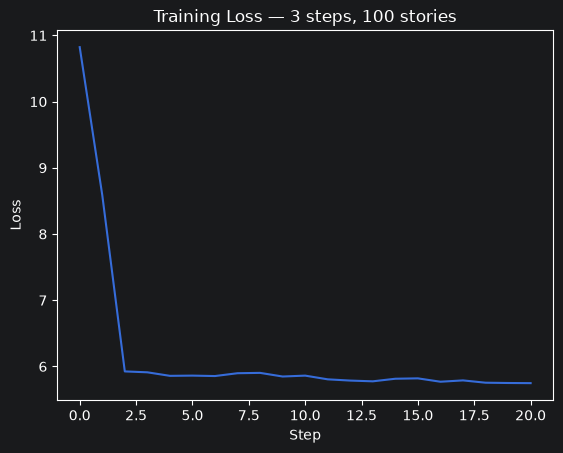

In [9]:
plt.plot(metrics_history["train_loss"])
plt.title("Training Loss — 3 steps, 100 stories")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

In [10]:
model_path = Path.cwd() / "lstm_model.orbax"

checkpointer = orbax.checkpoint.checkpointers.PyTreeCheckpointer()
checkpointer.save(model_path, nnx.state(model), force=True)